# Experiments with numerical solvers 

In [1]:
using Distributed  # for parallel computing
addprocs(4);
print(workers())

[2, 3, 4, 5]

In [2]:
@everywhere include("../tools/ode_solver.jl")
@everywhere include("../tools/setups/fpu.jl")
@everywhere using .FPU
@everywhere using ProgressMeter

In [3]:
@everywhere begin 
    const Dt = 1e0;
    const OMEGA = 50.;
    
    function phi_Dt(
        p::AbstractArray{T, 1}, 
        q::AbstractArray{T, 1}, 
        h::Float64, 
        method::String,
        omega::Float64 = OMEGA) where T<:AbstractFloat

        omega = convert(T, omega)
        return ode_solve(A!, METHODS[method], p, q, 0.0, Dt, round(Int, Dt/h), false, (omega^2)/2.)
    end
    
    function phi_Dt_N(
            p0::AbstractArray{T, 1}, 
            q0::AbstractArray{T, 1}, 
            N::Integer, 
            h::Float64,
            method::String,
            omega::Float64 = OMEGA) where T<:AbstractFloat
        
        progressbar = Progress(N)
        
        d = length(p0)
        P = zeros(T, d, N+1)
        Q = zeros(T, d, N+1)
        P[:, 1] = p0
        Q[:, 1] = q0
        
        for n in 1:N
            P[:, n+1], Q[:, n+1] = phi_Dt(P[:, n], Q[:, n], h, method, omega)
            next!(progressbar)
        end

        return P, Q
    end 
end

In [4]:
using LinearAlgebra
using Plots, LaTeXStrings

function compute_traj_err(sol, ref_sol) 
    # return norm(sol .- ref_sol)/norm(ref_sol)
    return norm(sol .- ref_sol)
end 

function compute_H_err(sol, ref_sol; omega=OMEGA)
    # return abs(compute_H(sol...; omega=omega) - compute_H(ref_sol...; omega=omega)) / abs(compute_H(ref_sol...; omega=omega))
    return abs(compute_H(sol...; omega=omega) - compute_H(ref_sol...; omega=omega))
end 

compute_H_err (generic function with 1 method)

## 1. Measure 1-step accuracy

In [5]:
p0, q0 = initial_condition(Float64, omega=OMEGA)

println("p0: ", p0)
println("q0: ", q0)
println("H0: ", compute_H(p0, q0, omega=OMEGA))
println("K0: ", compute_K(p0))
println("U0: ", compute_U(q0, omega=OMEGA))

p0: 

[0.0, 1.4142135623730951, 0.0, 0.0, 0.0, 0.0]
q0: [0.6929646455628166, 0.7212489168102785, 0.0, 0.0, 0.0, 0.0]
H0: 2.0012000800000003
K0: 1.0000000000000002
U0: 1.0012000800000003


In [6]:
p0_bf, q0_bf = initial_condition(BigFloat, omega=OMEGA)

println("p0: ", p0_bf)
println("q0: ", q0_bf)
println("H0: ", compute_H(p0_bf, q0_bf, omega=OMEGA))
println("K0: ", compute_K(p0_bf))
println("U0: ", compute_U(q0_bf, omega=OMEGA))

p0: BigFloat

[0.0, 1.414213562373095048801688724209698078569671875376948073176679737990732478462102, 0.0, 0.0, 0.0, 0.0]
q0: BigFloat[0.692964645562816573912827474862752058499139218934704555856573071615458914446436, 0.7212489168102784748888612493469460200705326564422435173201066663752735640156746, 0.0, 0.0, 0.0, 0.0]


H0: 2.001200079999999999999999999999999999999999999999999999999999999999999999999877
K0: 0.9999999999999999999999999999999999999999999999999999999999999999999999999999914
U0: 1.001200079999999999999999999999999999999999999999999999999999999999999999999877


In [7]:
p0_f256, q0_f256 = initial_condition(Float64x4, omega=OMEGA)

println("p0: ", p0_f256)
println("q0: ", q0_f256)
println("H0: ", compute_H(p0_f256, q0_f256, omega=OMEGA))
println("K0: ", compute_K(p0_f256))
println("U0: ", compute_U(q0_f256, omega=OMEGA))

p0: MultiFloat{Float64, 4}[0.0, 1.414213562373095048801688724209698078569671875376948073176679738104, 0.0, 0.0, 0.0, 0.0]
q0: MultiFloat{Float64, 4}[0.69296464556281657391282747486275205849913921893470455585657307155287, 0.7212489168102784748888612493469460200705326564422435173201066663259, 0.0, 0.0, 0.0, 0.0]


H0: 2.0012000800000000000000000000000000000000000000000000000000000004
K0: 1.00000000000000000000000000000000000000000000000000000000000000007596454196607839
U0: 1.001200080000000000000000000000000000000000000000000000000000000324


In [8]:
h_list = 2.0 .^[-6, -8, -10, -12, -14, -16, -18]

7-element Vector{Float64}:
 0.015625
 0.00390625
 0.0009765625
 0.000244140625
 6.103515625e-5
 1.52587890625e-5
 3.814697265625e-6

In [11]:
method_list = ["VelocityVerlet", "CalvoSanz4", "McAte5", "KahanLi6", "KahanLi8", "DPRKN12"]

6-element Vector{String}:
 "VelocityVerlet"
 "CalvoSanz4"
 "McAte5"
 "KahanLi6"
 "KahanLi8"
 "DPRKN12"

### 1.1 Float64

In [12]:
res = [phi_Dt(p0, q0, h, m) for h in h_list, m in method_list]

7×6 Matrix{Tuple{Vector{Float64}, Vector{Float64}}}:
 ([-0.43964, -1.08188, 0.602479, 0.530008, 0.0201803, 0.0197929], [0.508882, 0.548449, 0.388765, 0.388588, 0.00285476, 0.00275986])   …  ([-1.59725, 0.0744443, 0.575396, 0.55695, 0.0202271, 0.0196954], [0.517678, 0.539809, 0.387988, 0.389281, 0.00285472, 0.00276241])
 ([-1.5503, 0.0275428, 0.578138, 0.554211, 0.0202279, 0.0196985], [0.516379, 0.541098, 0.388004, 0.38927, 0.00285474, 0.0027622])        ([-1.59725, 0.0744443, 0.575396, 0.55695, 0.0202271, 0.0196954], [0.517678, 0.539809, 0.387988, 0.389281, 0.00285472, 0.00276241])
 ([-1.59446, 0.0716626, 0.575568, 0.556778, 0.0202271, 0.0196956], [0.517596, 0.539891, 0.387989, 0.38928, 0.00285472, 0.0027624])       ([-1.59725, 0.0744443, 0.575396, 0.55695, 0.0202271, 0.0196954], [0.517678, 0.539809, 0.387988, 0.389281, 0.00285472, 0.00276241])
 ([-1.59707, 0.074271, 0.575407, 0.556939, 0.0202271, 0.0196954], [0.517673, 0.539814, 0.387988, 0.389281, 0.00285472, 0.00276241])      ([-1.5

In [13]:
errors = [compute_traj_err(res[i, j], res[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-20, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel=L"|| \Phi u_0 - \Phi_{\mathrm{ref}} u_0 ||")
plot!(title="Ref: f64 DPRKN12 h=2^(-18)")
plot!(legend=:bottomright)
plot!(dpi=300)

savefig("./stability/omega=50/traj_err_f64.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/traj_err_f64.png"

In [14]:
errors = [compute_H_err(res[i, j], res[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-20, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel=L"| H(\Phi u_0) - H(\Phi_{\mathrm{ref}} u_0) |")
plot!(title="Ref: f64 DPRKN12 h=2^(-18)")
plot!(legend=:bottomright)
plot!(dpi=300)

savefig("./stability/omega=50/H_err_f64.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/H_err_f64.png"

In [15]:
sol = phi_Dt(p0, q0, 2^(-12), "McAte5")
ref_sol = phi_Dt(p0, q0, 2^(-14), "KahanLi8")
println("traj relerr = ", compute_traj_err(sol, ref_sol))
println("energy relerr = ", compute_H_err(sol, ref_sol))

traj relerr = 1.1847452888126762e-11
energy relerr = 2.360778239562933e-12


### 1.2 BigFloat

In [30]:
res_bf = [phi_Dt(p0_bf, q0_bf, h, m) for h in h_list, m in method_list]

┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596
┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596


7×5 Matrix{Tuple{Vector{BigFloat}, Vector{BigFloat}}}:
 ([NaN, NaN, NaN, Inf, -Inf, 3.97465e+1298747418474521919], [Inf, -Inf, Inf, -3.76746e+1222354549880186113, 3.76746e+1222354549880186113, -5.02902e+432915806158173973])  …  ([-1.06771, -0.453788, 0.564355, 0.567417, 0.0198942, 0.0198832], [0.521741, 0.535803, 0.38814, 0.38813, 0.00280081, 0.00279826])
 ([-1.40689, -0.114691, 0.569306, 0.562498, 0.0198997, 0.0198846], [0.526096, 0.531376, 0.388132, 0.388172, 0.00280107, 0.00279851])                                         ([-1.46022, -0.0613571, 0.560592, 0.571208, 0.0198973, 0.0198846], [0.53112, 0.526362, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.71654, 0.194953, 0.565889, 0.56591, 0.0198985, 0.0198836], [0.52781, 0.529672, 0.38813, 0.388168, 0.00280114, 0.0027986])                                              ([-1.45917, -0.0624068, 0.560588, 0.571212, 0.0198973, 0.0198846], [0.531124, 0.526359, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.50511, -0.016464, 0.56078

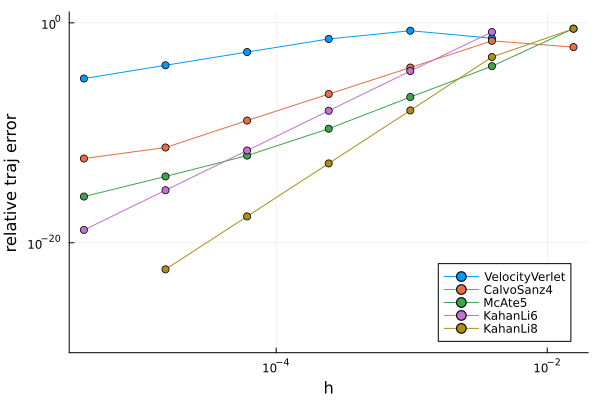

In [32]:
errors = [compute_traj_err(res_bf[i, j], res_bf[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-30, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative traj error")
plot!(legend=:bottomright)

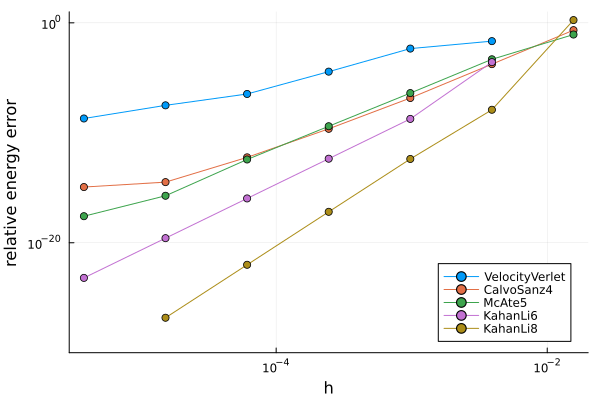

In [33]:
errors = [compute_H_err(res_bf[i, j], res_bf[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-30, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="relative energy error")
plot!(legend=:bottomright)

### 1.3 Float64x4

In [16]:
res_f256 = [phi_Dt(p0_f256, q0_f256, h, m) for h in h_list, m in method_list]

7×6 Matrix{Tuple{Vector{MultiFloat{Float64, 4}}, Vector{MultiFloat{Float64, 4}}}}:
 ([-0.43964, -1.08188, 0.602479, 0.530008, 0.0201803, 0.0197929], [0.508882, 0.548449, 0.388765, 0.388588, 0.00285476, 0.00275986])   …  ([-1.59725, 0.0744443, 0.575396, 0.55695, 0.0202271, 0.0196954], [0.517678, 0.539809, 0.387988, 0.389281, 0.00285472, 0.00276241])
 ([-1.5503, 0.0275428, 0.578138, 0.554211, 0.0202279, 0.0196985], [0.516379, 0.541098, 0.388004, 0.38927, 0.00285474, 0.0027622])        ([-1.59725, 0.0744443, 0.575396, 0.55695, 0.0202271, 0.0196954], [0.517678, 0.539809, 0.387988, 0.389281, 0.00285472, 0.00276241])
 ([-1.59446, 0.0716626, 0.575568, 0.556778, 0.0202271, 0.0196956], [0.517596, 0.539891, 0.387989, 0.38928, 0.00285472, 0.0027624])       ([-1.59725, 0.0744443, 0.575396, 0.55695, 0.0202271, 0.0196954], [0.517678, 0.539809, 0.387988, 0.389281, 0.00285472, 0.00276241])
 ([-1.59707, 0.074271, 0.575407, 0.556939, 0.0202271, 0.0196954], [0.517673, 0.539814, 0.387988, 0.389281, 0.0028

In [17]:
errors = [compute_traj_err(res_f256[i, j], res_f256[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-50, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel=L"|| \Phi u_0 - \Phi_{\mathrm{ref}} u_0 ||")
plot!(title="Ref: f64x4 DPRKN12 h=2^(-18)")
plot!(legend=:bottomright)
plot!(dpi=300)

savefig("./stability/omega=50/traj_err_f64x4.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/traj_err_f64x4.png"

In [18]:
errors = [compute_H_err(res_f256[i, j], res_f256[end, end]) for i in 1:length(h_list), j in 1:length(method_list)]

# plot(h_list[1:end-1, :], errors[1:end-1, :], marker=:circle, labels=permutedims(method_list))
plot(h_list, errors[:, 1:end-1], marker=:circle, labels=permutedims(method_list[1:end-1]))
plot!(h_list[1:end-1], errors[1:end-1, end], marker=:circle, labels=method_list[end])
plot!(ylim=[1e-50, 1e1])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel=L"| H(\Phi u_0) - H(\Phi_{\mathrm{ref}} u_0) |")
plot!(title="Ref: f64x4 DPRKN12 h=2^(-18)")
plot!(legend=:bottomright)
plot!(dpi=300)

savefig("./stability/omega=50/H_err_f64x4.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/H_err_f64x4.png"

In [39]:
p0_f256, q0_f256 = initial_condition(Float64x4, omega=50.)

sol = phi_Dt(p0_f256, q0_f256, 2^(-6), "CalvoSanz4", 50.)
ref_sol = phi_Dt(p0_f256, q0_f256, 2^(-18), "KahanLi8", 50.)
println("traj err = ", compute_traj_err(sol, ref_sol))
println("energy relerr = ", compute_H_err(sol, ref_sol, omega=50.)/abs(compute_H(ref_sol...)))

traj err = 0.0011074053741004416450347527368187522638975867599172810181876023189
energy relerr = 4.3335910372226179690142618757511936933725185195140123891116255493475909e-06


In [71]:
p0_f256, q0_f256 = initial_condition(Float64x4, omega=300.)

sol = phi_Dt(p0_f256, q0_f256, 2^(-14), "VelocityVerlet", 300.)
ref_sol = phi_Dt(p0_f256, q0_f256, 2^(-18), "KahanLi8", 300.)
println("traj err = ", compute_traj_err(sol, ref_sol))
println("energy relerr = ", compute_H_err(sol, ref_sol, omega=300.)/abs(compute_H(ref_sol..., omega=300.)))

traj err = 0.00419191095570618917931357733805071306701315182828934673484436886155
energy relerr = 3.383040019236175999201966073460178720355112739984360315050767210608e-07


### 1.4 Float64 vs Float64x4


In [48]:
h_list = 2.0 .^[-6, -8, -9, -10, -12, -14, -16, -18]
method_list = ["VelocityVerlet", "CalvoSanz4"]

p0, q0 = initial_condition(Float64, omega=300.)
p0_f256, q0_f256 = initial_condition(Float64x4, omega=300.)

res = [phi_Dt(p0, q0, h, m, 300.) for h in h_list, m in method_list]
res_f256 = [phi_Dt(p0_f256, q0_f256, h, m, 300.) for h in h_list, m in method_list]

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /Users/rfang/.julia/packages/SciMLBase/kTUaf/src/integrator_interface.jl:606
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /Users/rfang/.julia/packages/SciMLBase/kTUaf/src/integrator_interface.jl:606


8×2 Matrix{Tuple{Vector{MultiFloat{Float64, 4}}, Vector{MultiFloat{Float64, 4}}}}:
 ([NaN, NaN, NaN, 2.77874e+222, -2.77874e+222, 7.69154e+80], [4.22063e+159, -1.64865e+182, 1.64865e+182, -2.2317e+74, 2.2317e+74, -2.90875e+27])  …  ([-1.46133, -0.060218, 0.566309, 0.56548, 0.0198957, 0.0198847], [0.525518, 0.531985, 0.388135, 0.388153, 0.00280104, 0.00279849])
 ([-1.40689, -0.114691, 0.569306, 0.562498, 0.0198997, 0.0198846], [0.526096, 0.531376, 0.388132, 0.388172, 0.00280107, 0.00279851])                 ([-1.42843, -0.0931406, 0.560472, 0.571328, 0.0198972, 0.0198847], [0.531219, 0.526264, 0.388142, 0.388156, 0.00280114, 0.00279861])
 ([0.0953906, -1.61692, 0.564487, 0.567317, 0.0198946, 0.0198879], [0.530387, 0.527093, 0.388171, 0.388128, 0.00280112, 0.00279858])                 ([-1.45732, -0.0642606, 0.56058, 0.57122, 0.0198973, 0.0198847], [0.53113, 0.526353, 0.388141, 0.388157, 0.00280114, 0.00279861])
 ([-1.71654, 0.194953, 0.565889, 0.56591, 0.0198985, 0.0198836], [0.52781, 0

In [16]:
ref_sol = phi_Dt(p0_f256, q0_f256, 2.0^(-18), "DPRKN12", 300.)

(MultiFloat{Float64, 4}[-4.9948103322585140315046484600043915956029860041833642349143547357074, 3.472579813393517612904787882094474298461039895319824656122687037911, 0.5604380045617779879198262253437931757307609268045199241674146357808, 0.5715713846360273458994022773110621705978249641027813254471696861893, 0.01991952998656412915227652859429492845335432820677414440997909830405, 0.01989732628792286656101770123771286555658490971775882405048459948968], MultiFloat{Float64, 4}[0.53103090779726649080891216794906036218820316160732161166174291683591, 0.5259770370771282556426088535662309930989017493172181123021195496543, 0.3881980211775917279585754179278204262648207341315096847152586057608, 0.3883109892686052760601983443904158169960766194608211041299432431613, 0.00280378453336160060384931134956754922528604700805215531822948077669, 0.00280125175802448431315631235143051107214713836885926156906198546152])

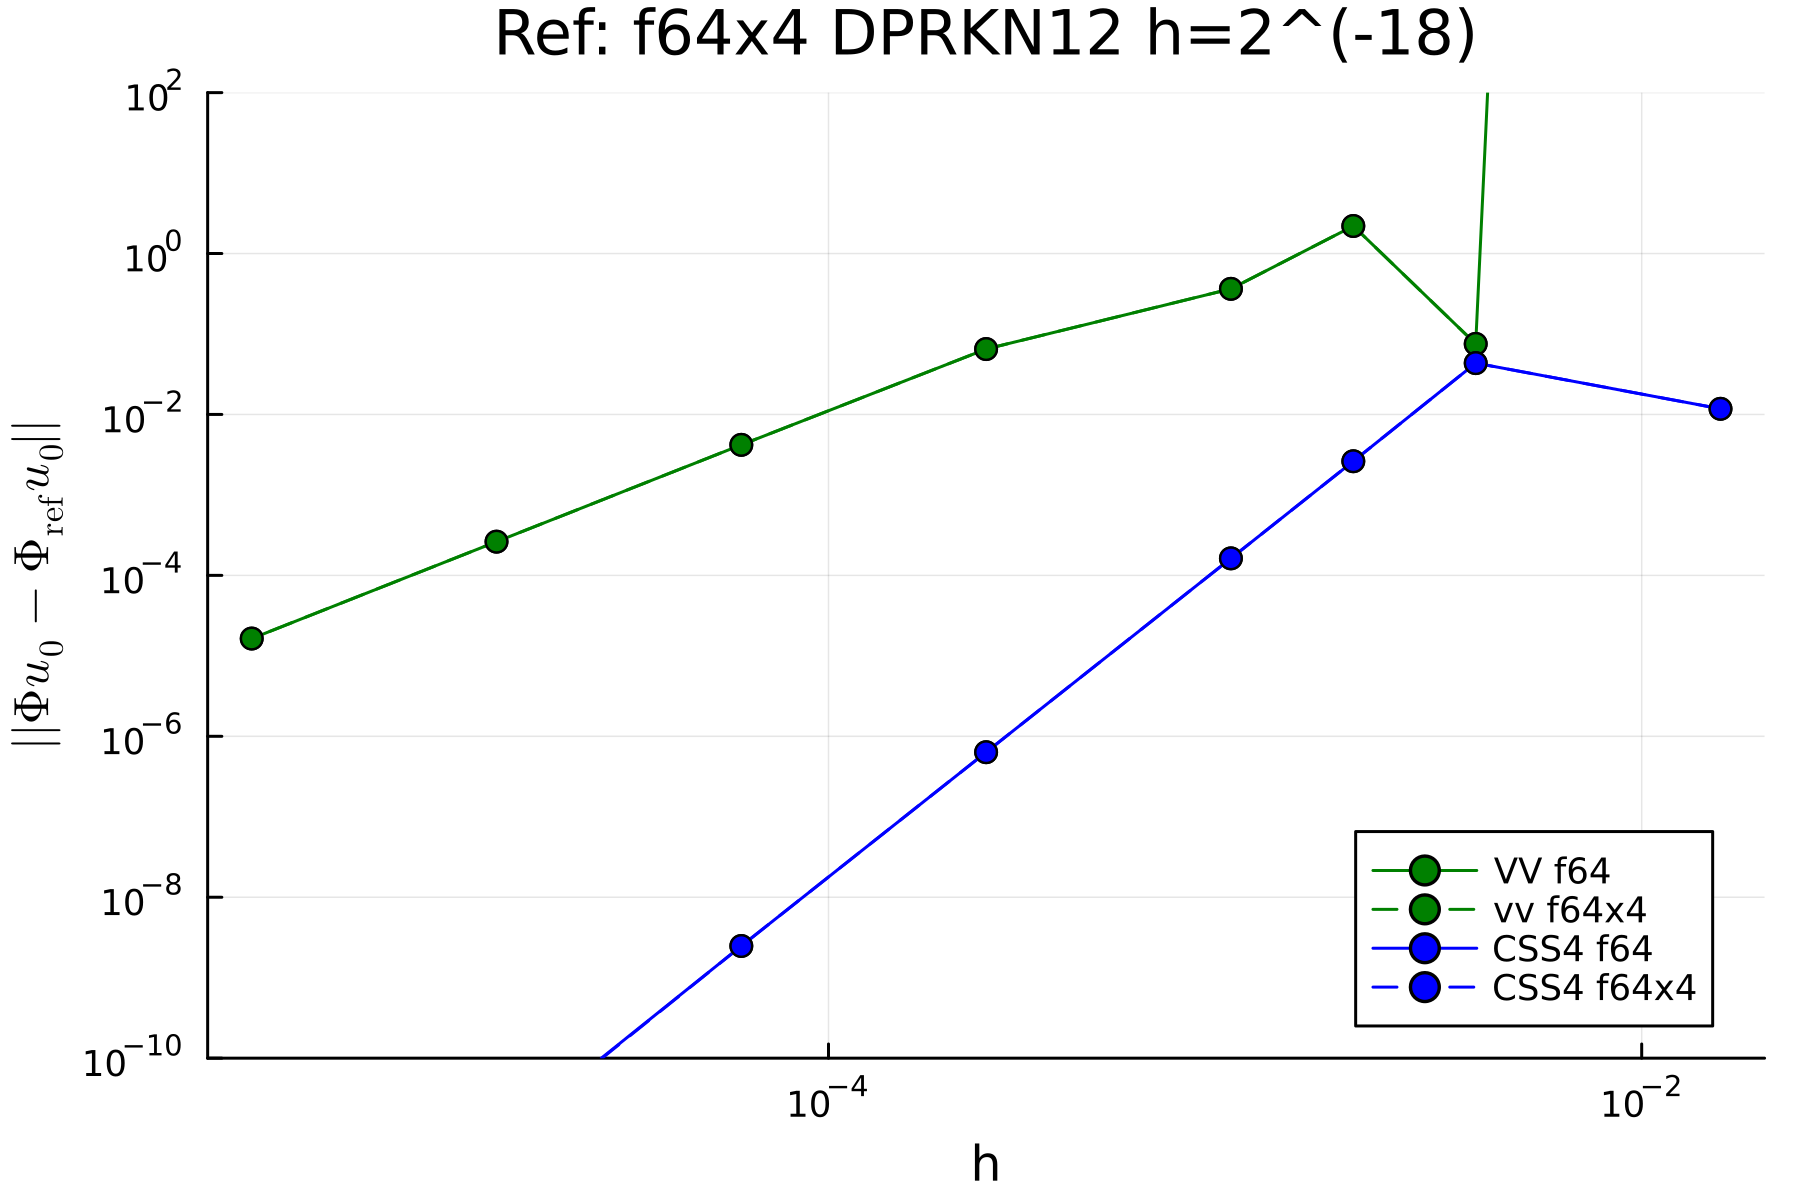

In [49]:
errors = [compute_traj_err(res[i, j], ref_sol) for i in 1:length(h_list), j in 1:length(method_list)]
errors_f256 = [compute_traj_err(res_f256[i, j], ref_sol) for i in 1:length(h_list), j in 1:length(method_list)]

plot(h_list, errors[:, 1], marker=:circle, seriescolor=:green, label="VV f64")
plot!(h_list, errors_f256[:, 1], marker=:circle, linestyle=:dash, seriescolor=:green, label="vv f64x4")
plot!(h_list, errors[:, 2], marker=:circle, seriescolor=:blue, label="CSS4 f64")
plot!(h_list, errors_f256[:, 2], marker=:circle, linestyle=:dash, seriescolor=:blue, label="CSS4 f64x4")
plot!(ylim=[1e-10, 1e2])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel=L"|| \Phi u_0 - \Phi_{\mathrm{ref}} u_0 ||")
plot!(title="Ref: f64x4 DPRKN12 h=2^(-18)")
plot!(legend=:bottomright)
plot!(dpi=300)

# savefig("./stability/omega=300/css4_vs_kl8_traj_err.png")

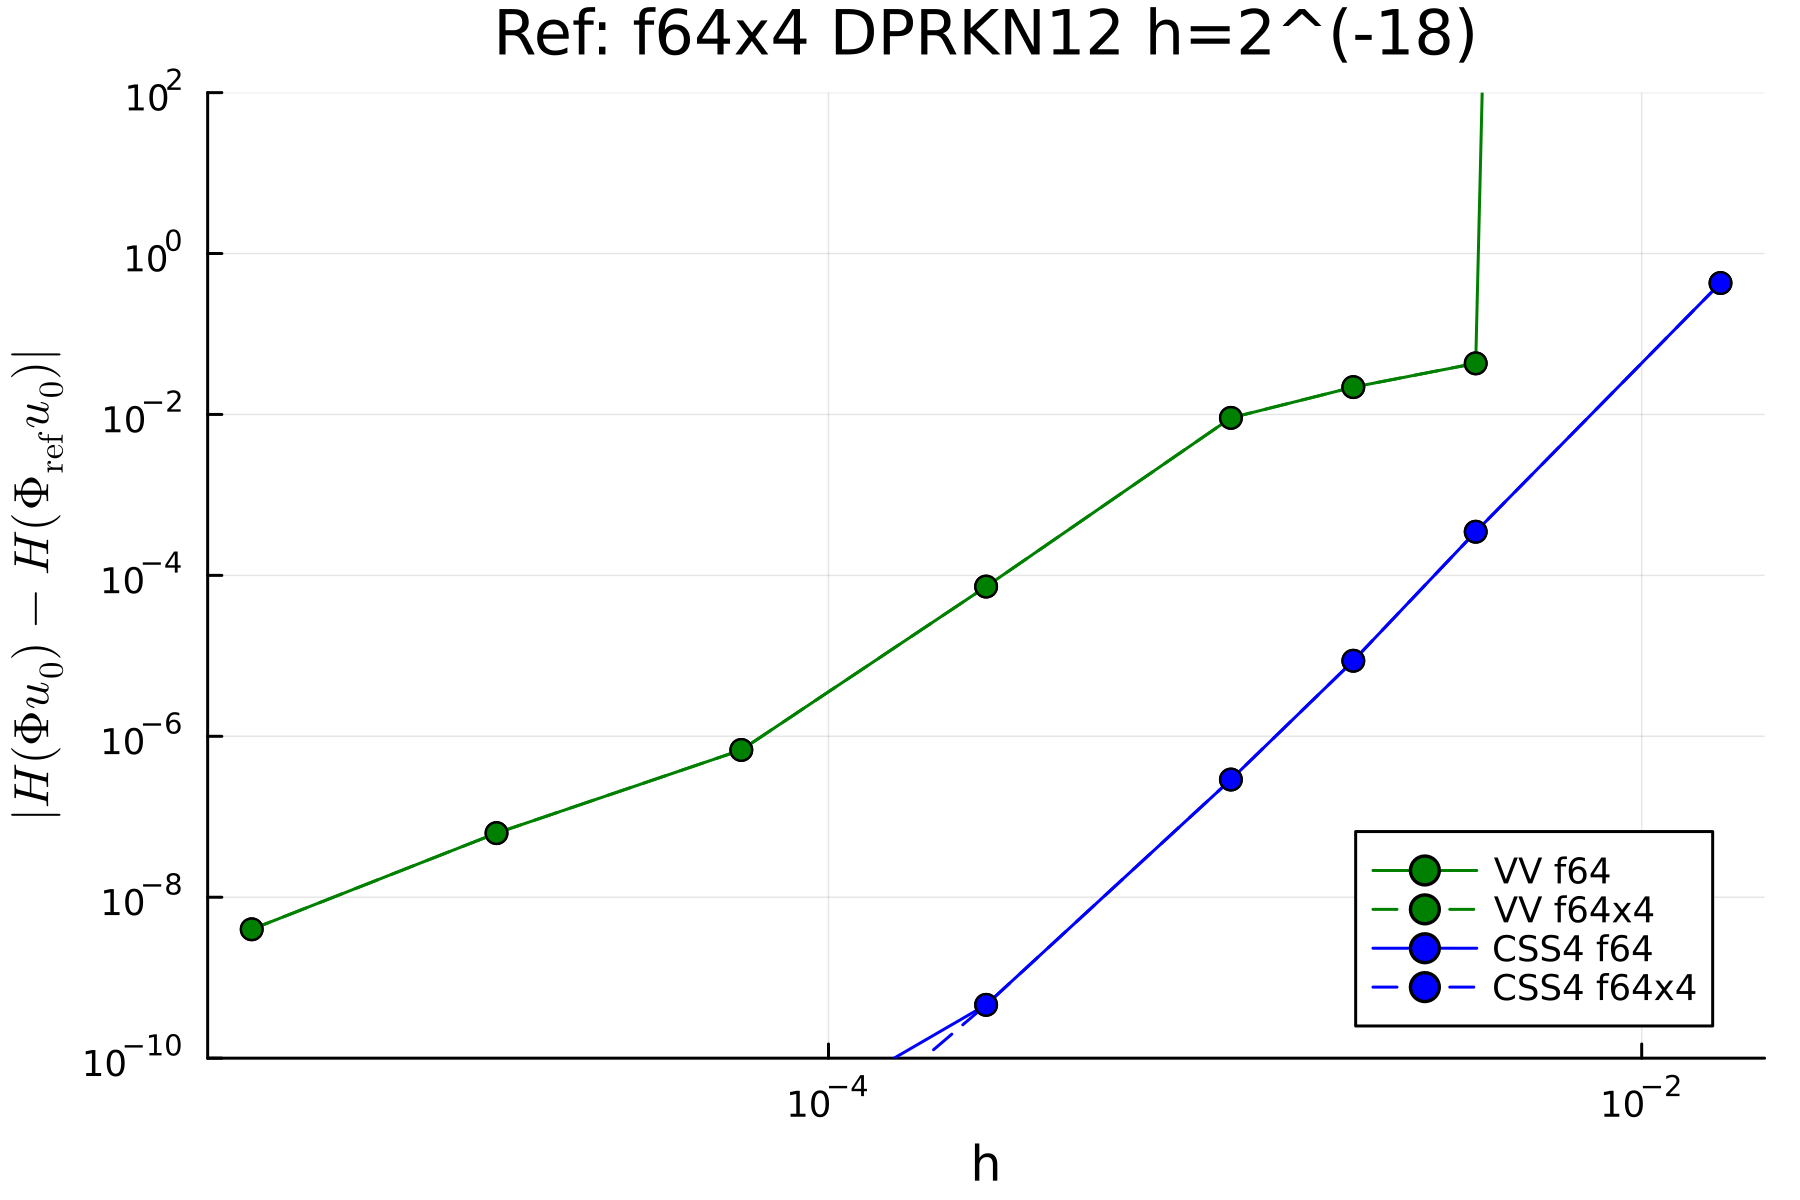

In [65]:
errors = [compute_H_err(res[i, j], ref_sol, omega=300.) for i in 1:length(h_list), j in 1:length(method_list)]
errors_f256 = [compute_H_err(res_f256[i, j], ref_sol, omega=300.) for i in 1:length(h_list), j in 1:length(method_list)]

plot(h_list, errors[:, 1], marker=:circle, seriescolor=:green, label="VV f64")
plot!(h_list, errors_f256[:, 1], marker=:circle, linestyle=:dash, seriescolor=:green, label="VV f64x4")
plot!(h_list, errors[:, 2], marker=:circle, seriescolor=:blue, label="CSS4 f64")
plot!(h_list, errors_f256[:, 2], marker=:circle, linestyle=:dash, seriescolor=:blue, label="CSS4 f64x4")
plot!(ylim=[1e-10, 1e2])
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel=L"| H(\Phi u_0) - H(\Phi_{\mathrm{ref}} u_0) |")
plot!(title="Ref: f64x4 DPRKN12 h=2^(-18)")
plot!(legend=:bottomright)
plot!(dpi=300)

# savefig("./stability/omega=300/css4_vs_kl8_H_err.png")

In [60]:
errors_f256

8×2 Matrix{MultiFloat{Float64, 4}}:
 NaN            0.0116971
   0.0699774    0.0407728
   0.237352     0.00251083
   0.411741     0.000156128
   0.0643479    6.0863e-07
   0.00402812   2.37532e-09
   0.000251738  8.40355e-12
   1.57336e-05  8.30553e-13

## 2. Measure runtime

In [8]:
using BenchmarkTools

In [23]:
h_list = 2.0 .^[-6, -8, -10, -12, -14, -16, -18]

7-element Vector{Float64}:
 0.015625
 0.00390625
 0.0009765625
 0.000244140625
 6.103515625e-5
 1.52587890625e-5
 3.814697265625e-6

In [24]:
method_list = ["VelocityVerlet", "CalvoSanz4", "McAte5", "KahanLi6", "KahanLi8", "DPRKN12"]

6-element Vector{String}:
 "VelocityVerlet"
 "CalvoSanz4"
 "McAte5"
 "KahanLi6"
 "KahanLi8"
 "DPRKN12"

### 2.1 Float64

In [73]:
@benchmark phi_Dt(p0, q0, 2^(-11), "VelocityVerlet", 300.)

BenchmarkTools.Trial: 8621 samples with 1 evaluation.
 Range (min … max):  513.042 μs …   4.344 ms  ┊ GC (min … max): 0.00% … 83.39%
 Time  (median):     566.792 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   578.419 μs ± 158.963 μs  ┊ GC (mean ± σ):  1.09% ±  3.63%

             ▁▃▃▄▅▅▆▇█▇▇▆▄▃▁▁                                    
  ▁▁▁▂▂▃▃▅▅▆▆█████████████████▆▆▅▄▅▄▃▃▃▃▂▂▂▂▂▁▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁ ▄
  513 μs           Histogram: frequency by time          676 μs <

 Memory estimate: 85.88 KiB, allocs estimate: 683.

In [27]:
runtimes = [@elapsed phi_Dt(p0, q0, h, m) for h in h_list, m in method_list]

plot(h_list, runtimes, marker=:circle, labels=permutedims(method_list))
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="runtime (sec)")
plot!(title=L"\Phi u_0 \quad \mathrm{(Float64)}")
plot!(legend=:bottomleft)
plot!(dpi=300)

savefig("./stability/omega=50/runtime_f64.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/runtime_f64.png"

### 2.2 BigFloat

In [39]:
@benchmark phi_Dt(p0_bf, q0_bf, 2^(-16), "McAte5")

BenchmarkTools.Trial: 2 samples with 1 evaluation.
 Range (min … max):  2.537 s …   2.585 s  ┊ GC (min … max): 9.25% … 9.26%
 Time  (median):     2.561 s              ┊ GC (median):    9.25%
 Time  (mean ± σ):   2.561 s ± 34.559 ms  ┊ GC (mean ± σ):  9.25% ± 0.01%

  █                                                       █  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  2.54 s         Histogram: frequency by time        2.59 s <

 Memory estimate: 3.54 GiB, allocs estimate: 73008318.

┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596
┌ Warning: Instability detected. Aborting
└ @ SciMLBase ~/.julia/packages/SciMLBase/VdcHg/src/integrator_interface.jl:596


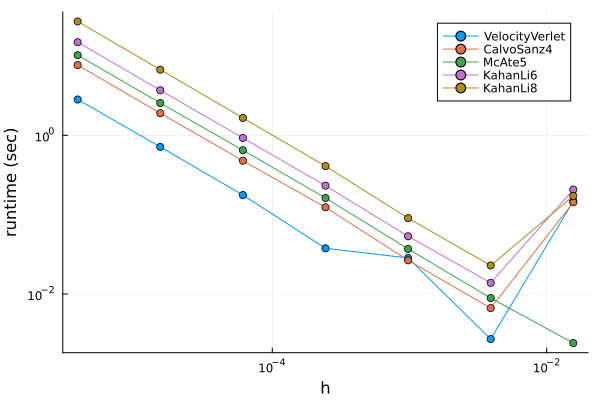

In [40]:
runtimes = [@elapsed phi_Dt(p0_bf, q0_bf, h, m) for h in h_list, m in method_list]

plot(h_list, runtimes, marker=:circle, labels=permutedims(method_list))
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="runtime (sec)")

### 2.3 Float64x4

In [28]:
@benchmark phi_Dt(p0_f256, q0_f256, 2^(-16), "McAte5")

BenchmarkTools.Trial: 8 samples with 1 evaluation.
 Range (min … max):  625.264 ms … 658.602 ms  ┊ GC (min … max): 0.00% … 3.18%
 Time  (median):     651.210 ms               ┊ GC (median):    2.73%
 Time  (mean ± σ):   644.414 ms ±  14.960 ms  ┊ GC (mean ± σ):  1.87% ± 1.53%

  █  █ █                                 █              █  ██ █  
  █▁▁█▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁██▁█ ▁
  625 ms           Histogram: frequency by time          659 ms <

 Memory estimate: 123.96 MiB, allocs estimate: 2556777.

In [30]:
runtimes = [@elapsed phi_Dt(p0_f256, q0_f256, h, m) for h in h_list, m in method_list]

plot(h_list, runtimes, marker=:circle, labels=permutedims(method_list))
plot!(xaxis=:log, yaxis=:log)
plot!(xlabel="h", ylabel="runtime (sec)")
plot!(title=L"\Phi u_0 \quad \mathrm{(Float64x4)}")
plot!(legend=:bottomleft)
plot!(dpi=300)

savefig("./stability/omega=50/runtime_f64x4.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/runtime_f64x4.png"

## 3. Measure stability 

In [6]:
include("../tools/utils.jl")
using Printf

In [ ]:
N = 1000
method = "CalvoSanz4"
omega = 300.
rootdir = "./stability/omega=300/css4"

p0, q0 = initial_condition(Float64, omega=omega)
p0_ptb = p0 .+ 1e-14;
q0_ptb = q0 .+ 1e-14;

p0_bf, q0_bf = initial_condition(BigFloat, omega=omega)
p0_ptb_bf = p0_bf .+ 1e-14;
q0_ptb_bf = q0_bf .+ 1e-14;

p0_f256, q0_f256 = initial_condition(Float64x4, omega=omega)
p0_ptb_f256 = p0_f256 .+ 1e-14;
q0_ptb_f256 = q0_f256 .+ 1e-14;

for h in 2.0 .^[-8, -9]
    # Float64
    P, Q = phi_Dt_N(p0, q0, N, h, method, omega)
    save_csv("$rootdir/f64/h=$(@sprintf("%.4e", h))/sol.csv", P, Q, Float64)
    
    P_ptb, Q_ptb = phi_Dt_N(p0_ptb, q0_ptb, N, h, method, omega)
    save_csv("$rootdir/f64/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb, Q_ptb, Float64)
    
#     # BigFloat
#     P_bf, Q_bf = phi_Dt_N(p0_bf, q0_bf, N, h, method, omega)
#     save_csv("$rootdir/bf/h=$(@sprintf("%.4e", h))/sol.csv", P_bf, Q_bf, BigFloat)
#     save_csv("$rootdir/bf_f64/h=$(@sprintf("%.4e", h))/sol.csv", P_bf, Q_bf, Float64)
    
#     P_ptb_bf, Q_ptb_bf = phi_Dt_N(p0_ptb_bf, q0_ptb_bf, N, h, method, omega)
#     save_csv("$rootdir/bf/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_bf, Q_ptb_bf, BigFloat)
#     save_csv("$rootdir/bf_f64/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_bf, Q_ptb_bf, Float64)
    
    # Float64x4
    P_f256, Q_f256 = phi_Dt_N(p0_f256, q0_f256, N, h, method, omega)
    save_csv("$rootdir/f64x4/h=$(@sprintf("%.4e", h))/sol.csv", P_f256, Q_f256, Float64x4)
    save_csv("$rootdir/f64x4_f64/h=$(@sprintf("%.4e", h))/sol.csv", P_f256, Q_f256, Float64)
    
    P_ptb_f256, Q_ptb_f256 = phi_Dt_N(p0_ptb_f256, q0_ptb_f256, N, h, method, omega)
    save_csv("$rootdir/f64x4/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_f256, Q_ptb_f256, Float64x4)
    save_csv("$rootdir/f64x4_f64/h=$(@sprintf("%.4e", h))/sol_ptb.csv", P_ptb_f256, Q_ptb_f256, Float64)
end

In [5]:
function plot_err_against_ref(
        compute_err,
        err_label,
        rootdir, 
        method, 
        dtype,
        h_list,
        ref_method, 
        ref_dtype, 
        ref_h,
        N
    )
    
    get_dtype(dtype) = Dict(
        "f64"=>Float64, 
        "f64x4"=>Float64x4, 
        "f64x4_f64"=>Float64,
        "bf"=>BigFloat, 
        "bf_f64"=>Float64
    )[dtype]
    get_dir(h) = "$rootdir/$method/$dtype/h=$(@sprintf("%.4e", h))/"

    P_ref, Q_ref = read_csv(
        "$rootdir/$ref_method/$ref_dtype/h=$(@sprintf("%.4e", ref_h))/sol.csv", 
        get_dtype(ref_dtype));

    errors = []
    for h in h_list
        errors_h = []
        P, Q = read_csv("$(get_dir(h))/sol.csv", get_dtype(dtype));

        for n in 2:N+1
            err = compute_err((P[:, n], Q[:, n]), (P_ref[:, n], Q_ref[:, n]))
            push!(errors_h, err)
        end

        push!(errors, (h, errors_h))
    end 

    pl = plot(dpi=300)
    for (h, errors_h) in errors
        plot!((1:N), errors_h[1:N], label="$dtype $(uppercase(method)) h=2^$(log2(h))")
    end
    plot!(yaxis=:log, ylim=[1e-30, 1e1])
    plot!(xlabel="n", ylabel=err_label)
    plot!(title="Ref: $ref_dtype $(uppercase(ref_method)) h=2^$(log2(ref_h))")
    plot!(legend=:bottomright)
    
    pl, errors
end


function plot_stability_err(
        compute_err::Function,
        err_label::LaTeXString,
        rootdir::String, 
        method::String, 
        dtype::String,
        h_list::Array{Float64, 1},
        N::Integer
    )

    get_dtype(dtype) = Dict(
        "f64"=>Float64, 
        "f64x4"=>Float64x4, 
        "f64x4_f64"=>Float64,
        "bf"=>BigFloat, 
        "bf_f64"=>Float64
    )[dtype]
    get_dir(h::Float64) = "$rootdir/$method/$dtype/h=$(@sprintf("%.4e", h))/"

    errors = []

    for h in h_list
        errors_h = []
        P, Q = read_csv("$(get_dir(h))/sol.csv", get_dtype(dtype));
        P_ptb, Q_ptb = read_csv("$(get_dir(h))/sol_ptb.csv", get_dtype(dtype));
        for n in 2:N+1
            err = compute_err((P_ptb[:, n], Q_ptb[:, n]), (P[:, n], Q[:, n]))
            push!(errors_h, err)
        end

        push!(errors, (h, errors_h))
    end 
    
    pl = plot(dpi=300)
    for (h, errors_h) in errors
        plot!((1:N), errors_h[1:N], label="$dtype $(uppercase(method)) h=2^$(log2(h))")
    end
    plot!(yaxis=:log, ylim=[1e-15, 1e0])
    plot!(xlabel="n", ylabel=err_label)
    plot!(legend=:topleft)
    
    pl, errors
end


function plot_stability_err(
        compute_err::Function,
        err_label::LaTeXString,
        rootdir::String, 
        method_list::Array{String, 1}, 
        dtype::String,
        h::Float64,
        N::Integer
    )

    get_dtype(dtype) = Dict(
        "f64"=>Float64, 
        "f64x4"=>Float64x4, 
        "f64x4_f64"=>Float64,
        "bf"=>BigFloat, 
        "bf_f64"=>Float64
    )[dtype]
    get_dir(m::String) = "$rootdir/$m/$dtype/h=$(@sprintf("%.4e", h))/"

    errors = []

    for m in method_list
        errors_m = []
        P, Q = read_csv("$(get_dir(m))/sol.csv", get_dtype(dtype));
        P_ptb, Q_ptb = read_csv("$(get_dir(m))/sol_ptb.csv", get_dtype(dtype));
        for n in 2:N+1
            err = compute_err((P_ptb[:, n], Q_ptb[:, n]), (P[:, n], Q[:, n]))
            push!(errors_m, err)
        end

        push!(errors, (m, errors_m))
    end 
    
    pl = plot(dpi=300)
    for (m, errors_m) in errors
        plot!((1:N), errors_m[1:N], label="$dtype $(uppercase(m)) h=2^$(log2(h))")
    end
    plot!(yaxis=:log, ylim=[1e-15, 1e0])
    plot!(xlabel="n", ylabel=err_label)
    plot!(legend=:topleft)
    
    pl, errors
end

plot_stability_err (generic function with 2 methods)

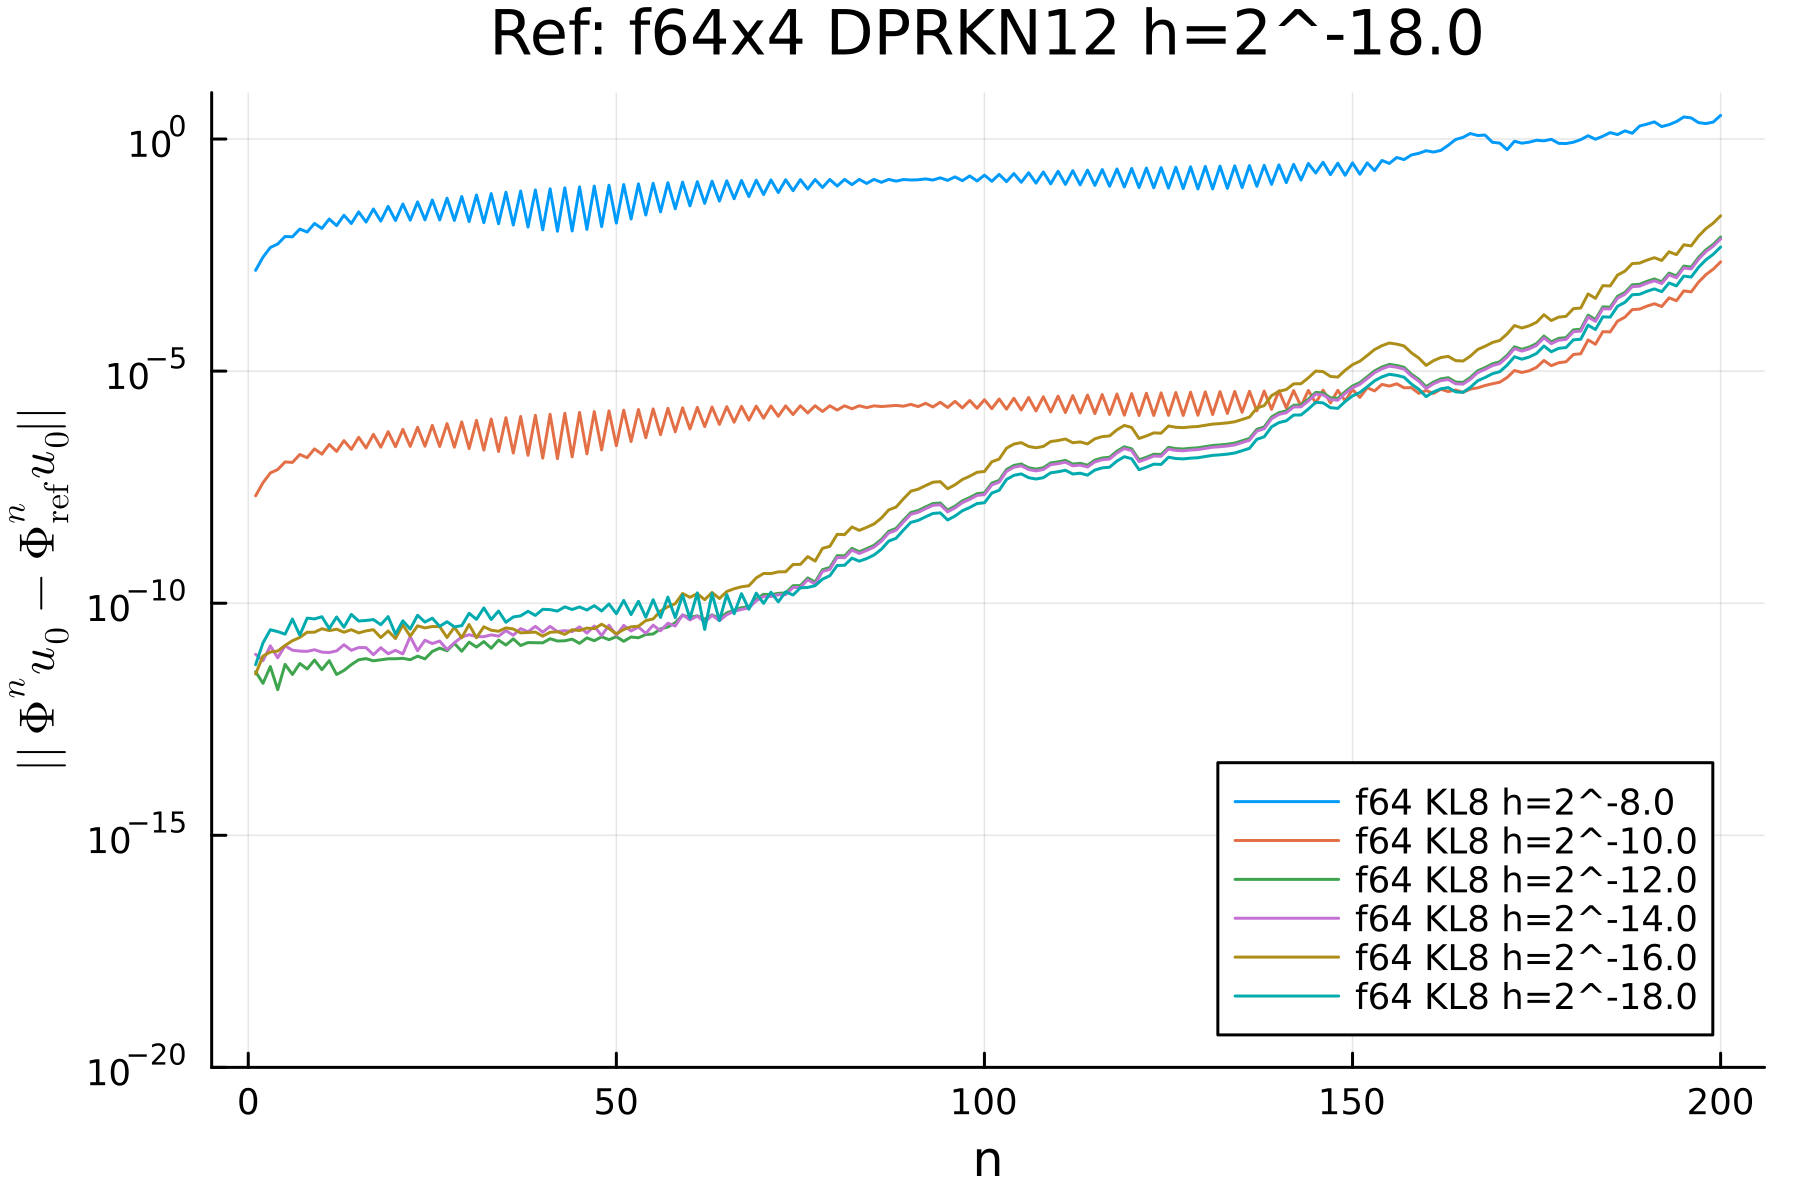

In [57]:
rootdir = "./stability/omega=300/"
method = "kl8"
dtype = "f64"
h_list = 2.0 .^[-8, -10, -12, -14, -16, -18]
ref_method = "dprkn12"
ref_dtype = "f64x4"
ref_h = 2^(-18)
N = 200

pl1, errors = plot_err_against_ref(compute_traj_err, L"||\Phi^n u_0 - \Phi^n_{\mathrm{ref}} u_0 ||",
    rootdir, method, dtype, h_list, ref_method, ref_dtype, ref_h, N)
pl1
# plot!(1:200, (1:200)*1e-16)
plot!(ylim=[1e-20, 1e1])
# savefig(pl1, 
#     "$rootdir/$method/$dtype/traj_err_against_ref_$(ref_method)_h=$(@sprintf("%.4e", ref_h))_N$N.png")

In [28]:
rootdir = "./stability/omega=50/"
method = "css4"
dtype = "f64"
h_list = 2.0 .^[-8, -10, -12, -14]
ref_method = "dprkn12"
ref_dtype = "f64x4"
ref_h = 2^(-18)
N = 200

pl2, errors = plot_err_against_ref(compute_H_err, L"|H(\Phi^n u_0) - H(\Phi^n_{\mathrm{ref}} u_0)|",
    rootdir, method, dtype, h_list, ref_method, ref_dtype, ref_h, N)
pl2
plot!(ylim=[1e-20, 1e1])
savefig(pl2, 
    "$rootdir/$method/$dtype/H_err_against_ref_$(ref_method)_h=$(@sprintf("%.4e", ref_h))_N$N.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/css4/f64/H_err_against_ref_dprkn12_h=3.8147e-06_N200.png"

In [22]:
rootdir = "./stability/omega=300/"
method = "kl8"
dtype = "f64x4"
h_list = 2.0 .^[-18]
N = 1000

pl3, errors = plot_stability_err(compute_traj_err, L"|| \Phi^n u_0 - \Phi^n u_0^{\mathrm{ptb}}||",
    rootdir, method, dtype, h_list, N)
plot!(ylim=[1e-15, 1e5])
savefig(pl3, 
    "$rootdir/$method/$dtype/stability_traj_err_N$N.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=300/kl8/f64x4/stability_traj_err_N1000.png"

In [23]:
rootdir = "./stability/omega=300/"
method = "kl8"
dtype = "f64x4"
h_list = 2.0 .^[-18]
N = 1000

pl4, errors = plot_stability_err(compute_H_err, L"|H(\Phi^n u_0) - H(\Phi^n u_0^{\mathrm{ptb}})|",
    rootdir, method, dtype, h_list, N)
# plot!(ylim=[1e-50, 1e1])
savefig(pl4, 
    "$rootdir/$method/$dtype/stability_H_err_N$N.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=300/kl8/f64x4/stability_H_err_N1000.png"

In [68]:
rootdir = "./stability/omega=50/"
method_list = ["css4", "ma5", "kl6", "kl8", "dprkn12"]
dtype = "f64x4"
h = 2.0 .^ (-18)
N = 200

pl5, errors = plot_stability_err(compute_traj_err, L"|| \Phi^n u_0 - \Phi^n u_0^{\mathrm{ptb}}||",
    rootdir, method_list, dtype, h, N)
pl5
plot!(ylim=[1e-15, 1e0])
savefig(pl5, 
    "$rootdir/stability_traj_err_$(dtype)_h=$(@sprintf("%.4e", h)).png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/stability_traj_err_f64x4_h=3.8147e-06.png"

In [71]:
rootdir = "./stability/omega=50/"
method_list = ["css4", "ma5", "kl6", "kl8", "dprkn12"]
dtype = "f64x4"
h = 2.0 .^ (-18)
N = 200

pl6, errors = plot_stability_err(compute_H_err, L"|H(\Phi^n u_0) - H(\Phi^n u_0^{\mathrm{ptb}})|",
    rootdir, method_list, dtype, h, N)
pl6
plot!(ylim=[1e-15, 1e1])
savefig(pl6, 
    "$rootdir/stability_H_err_$(dtype)_h=$(@sprintf("%.4e", h)).png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=50/stability_H_err_f64x4_h=3.8147e-06.png"

In [14]:
rootdir = "./stability/omega=300/"
N = 1000
# compute_err(sol, ref_sol) = compute_traj_err(sol, ref_sol)
# err_label = L"||\Phi^n u_0 - \Phi^n_{\mathrm{ref}} u_0 ||"
compute_err(sol, ref_sol) = compute_H_err(sol, ref_sol; omega=300.)
err_label = L"|H(\Phi^n u_0) - H(\Phi^n_{\mathrm{ref}} u_0)|"


get_dtype(dtype::String) = Dict(
    "f64"=>Float64, 
    "f64x4"=>Float64x4, 
    "f64x4_f64"=>Float64,
    "bf"=>BigFloat, 
    "bf_f64"=>Float64
)[dtype]
get_dir(method::String, dtype::String, h::Float64) = "$rootdir/$method/$dtype/h=$(@sprintf("%.4e", h))/"

ref_dir = get_dir("dprkn12", "f64x4", 2.0 .^ (-18))
P_ref, Q_ref = read_csv("$(ref_dir)/sol.csv", get_dtype("f64x4"));

pl = plot(dpi=300)


# errors = []
# P, Q = read_csv("$(get_dir("css4", "f64", 2.0 .^ (-8)))/sol.csv", get_dtype("f64"));
# for n in 2:N+1
#     err = compute_err((P[:, n], Q[:, n]), (P_ref[:, n], Q_ref[:, n]))
#     push!(errors, err)
# end
# plot!((1:N), errors[1:N], seriescolor=:red, label="f64 CSS4 h=2^-8.0")

# errors = []
# P, Q = read_csv("$(get_dir("css4", "f64x4", 2.0 .^ (-8)))/sol.csv", get_dtype("f64x4"));
# for n in 2:N+1
#     err = compute_err((P[:, n], Q[:, n]), (P_ref[:, n], Q_ref[:, n]))
#     push!(errors, err)
# end
# plot!((1:N), errors[1:N], seriescolor=:red, linestyle=:dash, label="f64x4 CSS4 h=2^-8.0")

# errors = []
# P, Q = read_csv("$(get_dir("css4", "f64", 2.0 .^ (-9)))/sol.csv", get_dtype("f64"));
# for n in 2:N+1
#     err = compute_err((P[:, n], Q[:, n]), (P_ref[:, n], Q_ref[:, n]))
#     push!(errors, err)
# end
# plot!((1:N), errors[1:N], seriescolor=:green, label="f64 CSS4 h=2^-9.0")

# errors = []
# P, Q = read_csv("$(get_dir("css4", "f64x4", 2.0 .^ (-9)))/sol.csv", get_dtype("f64x4"));
# for n in 2:N+1
#     err = compute_err((P[:, n], Q[:, n]), (P_ref[:, n], Q_ref[:, n]))
#     push!(errors, err)
# end
# plot!((1:N), errors[1:N], seriescolor=:green, linestyle=:dash, label="f64x4 CSS4 h=2^-9.0")

errors = []
P, Q = read_csv("$(get_dir("kl8", "f64", 2.0 .^ (-18)))/sol.csv", get_dtype("f64"));
for n in 2:N+1
    err = compute_err((P[:, n], Q[:, n]), (P_ref[:, n], Q_ref[:, n]))
    push!(errors, err)
end
plot!((1:N), errors[1:N], seriescolor=:blue, label="f64 KL8 h=2^-18.0")

errors = []
P, Q = read_csv("$(get_dir("kl8", "f64x4", 2.0 .^ (-18)))/sol.csv", get_dtype("f64x4"));
for n in 2:N+1
    err = compute_err((P[:, n], Q[:, n]), (P_ref[:, n], Q_ref[:, n]))
    push!(errors, err)
end
plot!((1:N), errors[1:N], seriescolor=:blue, linestyle=:dash, label="f64x4 KL8 h=2^-18.0")


plot!(yaxis=:log, ylim=[1e-35, 1e2])
plot!(xlabel="n", ylabel=err_label)
plot!(title="Ref: f64x4 DPRKN12 h=2^-18.0")
plot!(legend=:topright)

savefig(pl, "$rootdir/f64_vs_f64x4_kl8_global_H_err_N$N.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=300/f64_vs_f64x4_kl8_global_H_err_N1000.png"

In [7]:
errors

200-element Vector{Any}:
 1.106708422422451037157189642697178054975466867106806683715566234299e-27
 2.122640752043053426763660995896369231529900052653219219515387261148e-27
 3.438426773671328889590850044860065963810263206977747765651482126142e-27
 4.067541488131209732429156666025308370059629311020813295267613147454e-27
 5.940403518292725681987627809994258385518240668476780258277870137934e-27
 5.805800694482580916406007560077139937305042906565241908284364190705e-27
 8.593889063065960834428627580593569755639463176332204808845188508175e-27
 7.341715833522595058219708529539938379985412831576049789324609417766e-27
 1.134718129462314647627478768157382549959516249075879640042181800093e-26
 8.74984852709711399629845266534126967363471501441722642324317566701e-27
 ⋮
 2.2224714246696276440163341206193484202189292356446033112485487450275e-23
 3.4163397455180014478691882111155811503901744397047263449201849363017e-23
 2.9611562743174716767815425598047018608671745767749857844303430207153e-23
 4.82873

## 4. Energy profile 

In [13]:
function plot_stiff_energies(
        rootdir, 
        method, 
        dtype,
        h,
        fname,
        N
    )
    
    get_dtype(dtype) = Dict(
        "f64"=>Float64, 
        "f64x4"=>Float64x4, 
        "f64x4_f64"=>Float64,
        "bf"=>BigFloat, 
        "bf_f64"=>Float64
    )[dtype]

    P, Q = read_csv(
        "$rootdir/$method/$dtype/h=$(@sprintf("%.4e", h))/$fname", 
        get_dtype(dtype));
    
    omega = convert(get_dtype(dtype), OMEGA)
    I = hcat([compute_I(P[:, n], Q[:, n]; omega=omega) for n in 1:N+1]...)
    I_tot = sum(I, dims=1)

    pl = plot(dpi=300)
    plot!((0:N), I[1, 1:N+1], label=L"I_1")
    plot!((0:N), I[2, 1:N+1], label=L"I_2")
    plot!((0:N), I[3, 1:N+1], label=L"I_3")
    plot!((0:N), I_tot', label=L"I_{total}")
    plot!(xlabel="n", ylabel="stiff energies")
    plot!(title="$dtype $(uppercase(method)) h=2^$(log2(h))")
    plot!(legend=:outerbottomright)

    pl
end

plot_stiff_energies (generic function with 1 method)

In [25]:
rootdir = "./stability/omega=300/"
method = "dprkn12"
dtype = "f64x4"
h = 2.0 .^ (-18)
fname = "sol.csv"
N = 1000


pl = plot_stiff_energies(rootdir, method, dtype, h, fname, N)
savefig(pl, "$rootdir/$method/$dtype/h=$(@sprintf("%.4e", h))/sol.png")

"/Users/rfang/Documents/school/utexas/research/tsai/learnsolnmap_code/learnsolnmap/generate_data/stability/omega=300/dprkn12/f64x4/h=3.8147e-06/sol.png"